In [1]:
from pathlib import Path

import pandas as pd

from ugradiolab import Spectrum

from utils.combine import combine_capture_dir
from utils.lab_2_0_preview_plot import plot_dataset_pair
from utils.preview_data import build_cached_preview_rows, combined_lo_files_exist, load_spectra_cached


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
DATA_ROOT = Path('data')
LO_FREQS_MHZ = (1420, 1421)

DATASETS = [
    {
        'label': 'standard',
        'raw_dir': DATA_ROOT / 'standard',
        'combined_dir': DATA_ROOT / 'standard_combined',
    },
    {
        'label': 'cygnus-x',
        'raw_dir': DATA_ROOT / 'cygnus-x',
        'combined_dir': DATA_ROOT / 'cygnus-x_combined',
    },
    {
        'label': 'human',
        'raw_dir': DATA_ROOT / 'human',
        'combined_dir': DATA_ROOT / 'human_combined',
    },
    {
        'label': 'SGP',
        'raw_dir': DATA_ROOT / 'SGP',
        'combined_dir': DATA_ROOT / 'SGP_combined',
    },
    {
        'label': 'cold_ref',
        'raw_dir': DATA_ROOT / 'cold_ref',
        'combined_dir': DATA_ROOT / 'cold_ref_combined',
    },
]


In [3]:
# Preview-data helpers are imported from utils.preview_data.


In [4]:
for dataset in DATASETS:
    label = dataset['label']
    raw_dir = dataset['raw_dir']
    combined_dir = dataset['combined_dir']

    if not combined_lo_files_exist(combined_dir, lo_freqs_mhz=LO_FREQS_MHZ):
        print()
        print('=' * 80)
        print(f'[{label}]')
        combine_capture_dir(raw_dir, combined_dir)



[cold_ref]
Running: /Users/junruiting/GitHub/ay-121/.venv/bin/python utils/combine.py ../../data/lab02/cold_ref ../../data/lab02/cold_ref_combined


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Input  : ../../data/lab02/cold_ref
Output : ../../data/lab02/cold_ref_combined

[GAL-1420] Loading 16 files...
  COLD-1420-0_obs_20260307_183834.npz  nblocks=2048
  COLD-1420-1_obs_20260307_183857.npz  nblocks=2048
  COLD-1420-2_obs_20260307_183923.npz  nblocks=2048
  COLD-1420-3_obs_20260307_184000.npz  nblocks=2048
  COLD-1420-4_obs_20260307_184036.npz  nblocks=2048
  COLD-1420-5_obs_20260307_184053.npz  nblocks=2048
  COLD-1420-6_obs_20260307_184108.npz  nblocks=2048
  COLD-1420-7_obs_20260307_184125.npz  nblocks=2048
  COLD-1420-8_obs_20260307_184140.npz  nblocks=2048
  COLD-1420-9_obs_20260307_184155.npz  nblocks=2048
  COLD-1420-10_obs_20260307_184212.npz  nblocks=2048
  COLD-1420-11_obs_20260307_184227.npz  nblocks=2048
  COLD-1420-12_obs_20260307_184314.npz  nblocks=2048
  COLD-1420-13_obs_20260307_184329.npz  nblocks=2048
  COLD-1420-14_obs_20260307_184356.npz  nblocks=2048
  COLD-1420-15_obs_20260307_184427.npz  nblocks=2048
  Combined: nblocks=32768, nsamples=8192
  -> ../..

In [5]:
pairs_by_dataset: dict[str, dict[int, Spectrum]] = {}

for dataset in DATASETS:
    label = dataset['label']
    combined_dir = dataset['combined_dir']

    print()
    print('=' * 80)
    print(f'[{label}]')

    spectrum_pairs = load_spectra_cached(combined_dir)
    pairs_by_dataset[label], rows = build_cached_preview_rows(spectrum_pairs)
    display(pd.DataFrame(rows).set_index('LO (MHz)'))



[standard]
Loading pre-processed Spectrum from ../../data/lab02/standard_combined_spectra


,filename,nblocks,nsamples,alt (deg),az (deg),JD,total_power,sigma
LO (MHz),,,,,,,,
1420,GAL-1420_combined.npz,32768,32768,64.68,7.03,2.461105e+06,38.825188,0.001243
1421,GAL-1421_combined.npz,32768,32768,64.68,7.03,2.461105e+06,37.037964,0.001191



[cygnus-x]
Loading pre-processed Spectrum from ../../data/lab02/cygnus-x_combined_spectra


,filename,nblocks,nsamples,alt (deg),az (deg),JD,total_power,sigma
LO (MHz),,,,,,,,
1420,GAL-1420_combined.npz,32768,32768,46.84,292.6,2.461105e+06,44.314823,0.001419
1421,GAL-1421_combined.npz,32768,32768,46.84,292.6,2.461105e+06,43.744370,0.001405



[human]
Loading pre-processed Spectrum from ../../data/lab02/human_combined_spectra


,filename,nblocks,nsamples,alt (deg),az (deg),JD,total_power,sigma
LO (MHz),,,,,,,,
1420,GAL-1420_combined.npz,16384,8192,0.0,0.0,2.461096e+06,110.431198,0.010006
1421,GAL-1421_combined.npz,16384,8192,0.0,0.0,2.461096e+06,107.425591,0.009727



[SGP]
Loading pre-processed Spectrum from ../../data/lab02/SGP_combined_spectra


,filename,nblocks,nsamples,alt (deg),az (deg),JD,total_power,sigma
LO (MHz),,,,,,,,
1420,GAL-1420_combined.npz,32768,32768,21.19,156.64,2.461105e+06,52.948280,0.002312
1421,GAL-1421_combined.npz,32768,32768,21.19,156.64,2.461105e+06,50.223057,0.002290



[cold_ref]
Generating Spectrum cache: ../../data/lab02/cold_ref_combined -> ../../data/lab02/cold_ref_combined_spectra


,filename,nblocks,nsamples,alt (deg),az (deg),JD,total_power,sigma
LO (MHz),,,,,,,,
1420,GAL-1420_combined.npz,32768,8192,50.0,50.0,2.461108e+06,30.980419,0.001986
1421,GAL-1421_combined.npz,32768,8192,50.0,50.0,2.461108e+06,33.385361,0.002141



[standard]
R / 1/R summary (standard combined)
--------------------------------------------------------------------------------
total_power_1420 = 38.8251876831
total_power_1421 = 37.0379638672
R_total         = 1.0482538355
1/R_total       = 0.9539674134


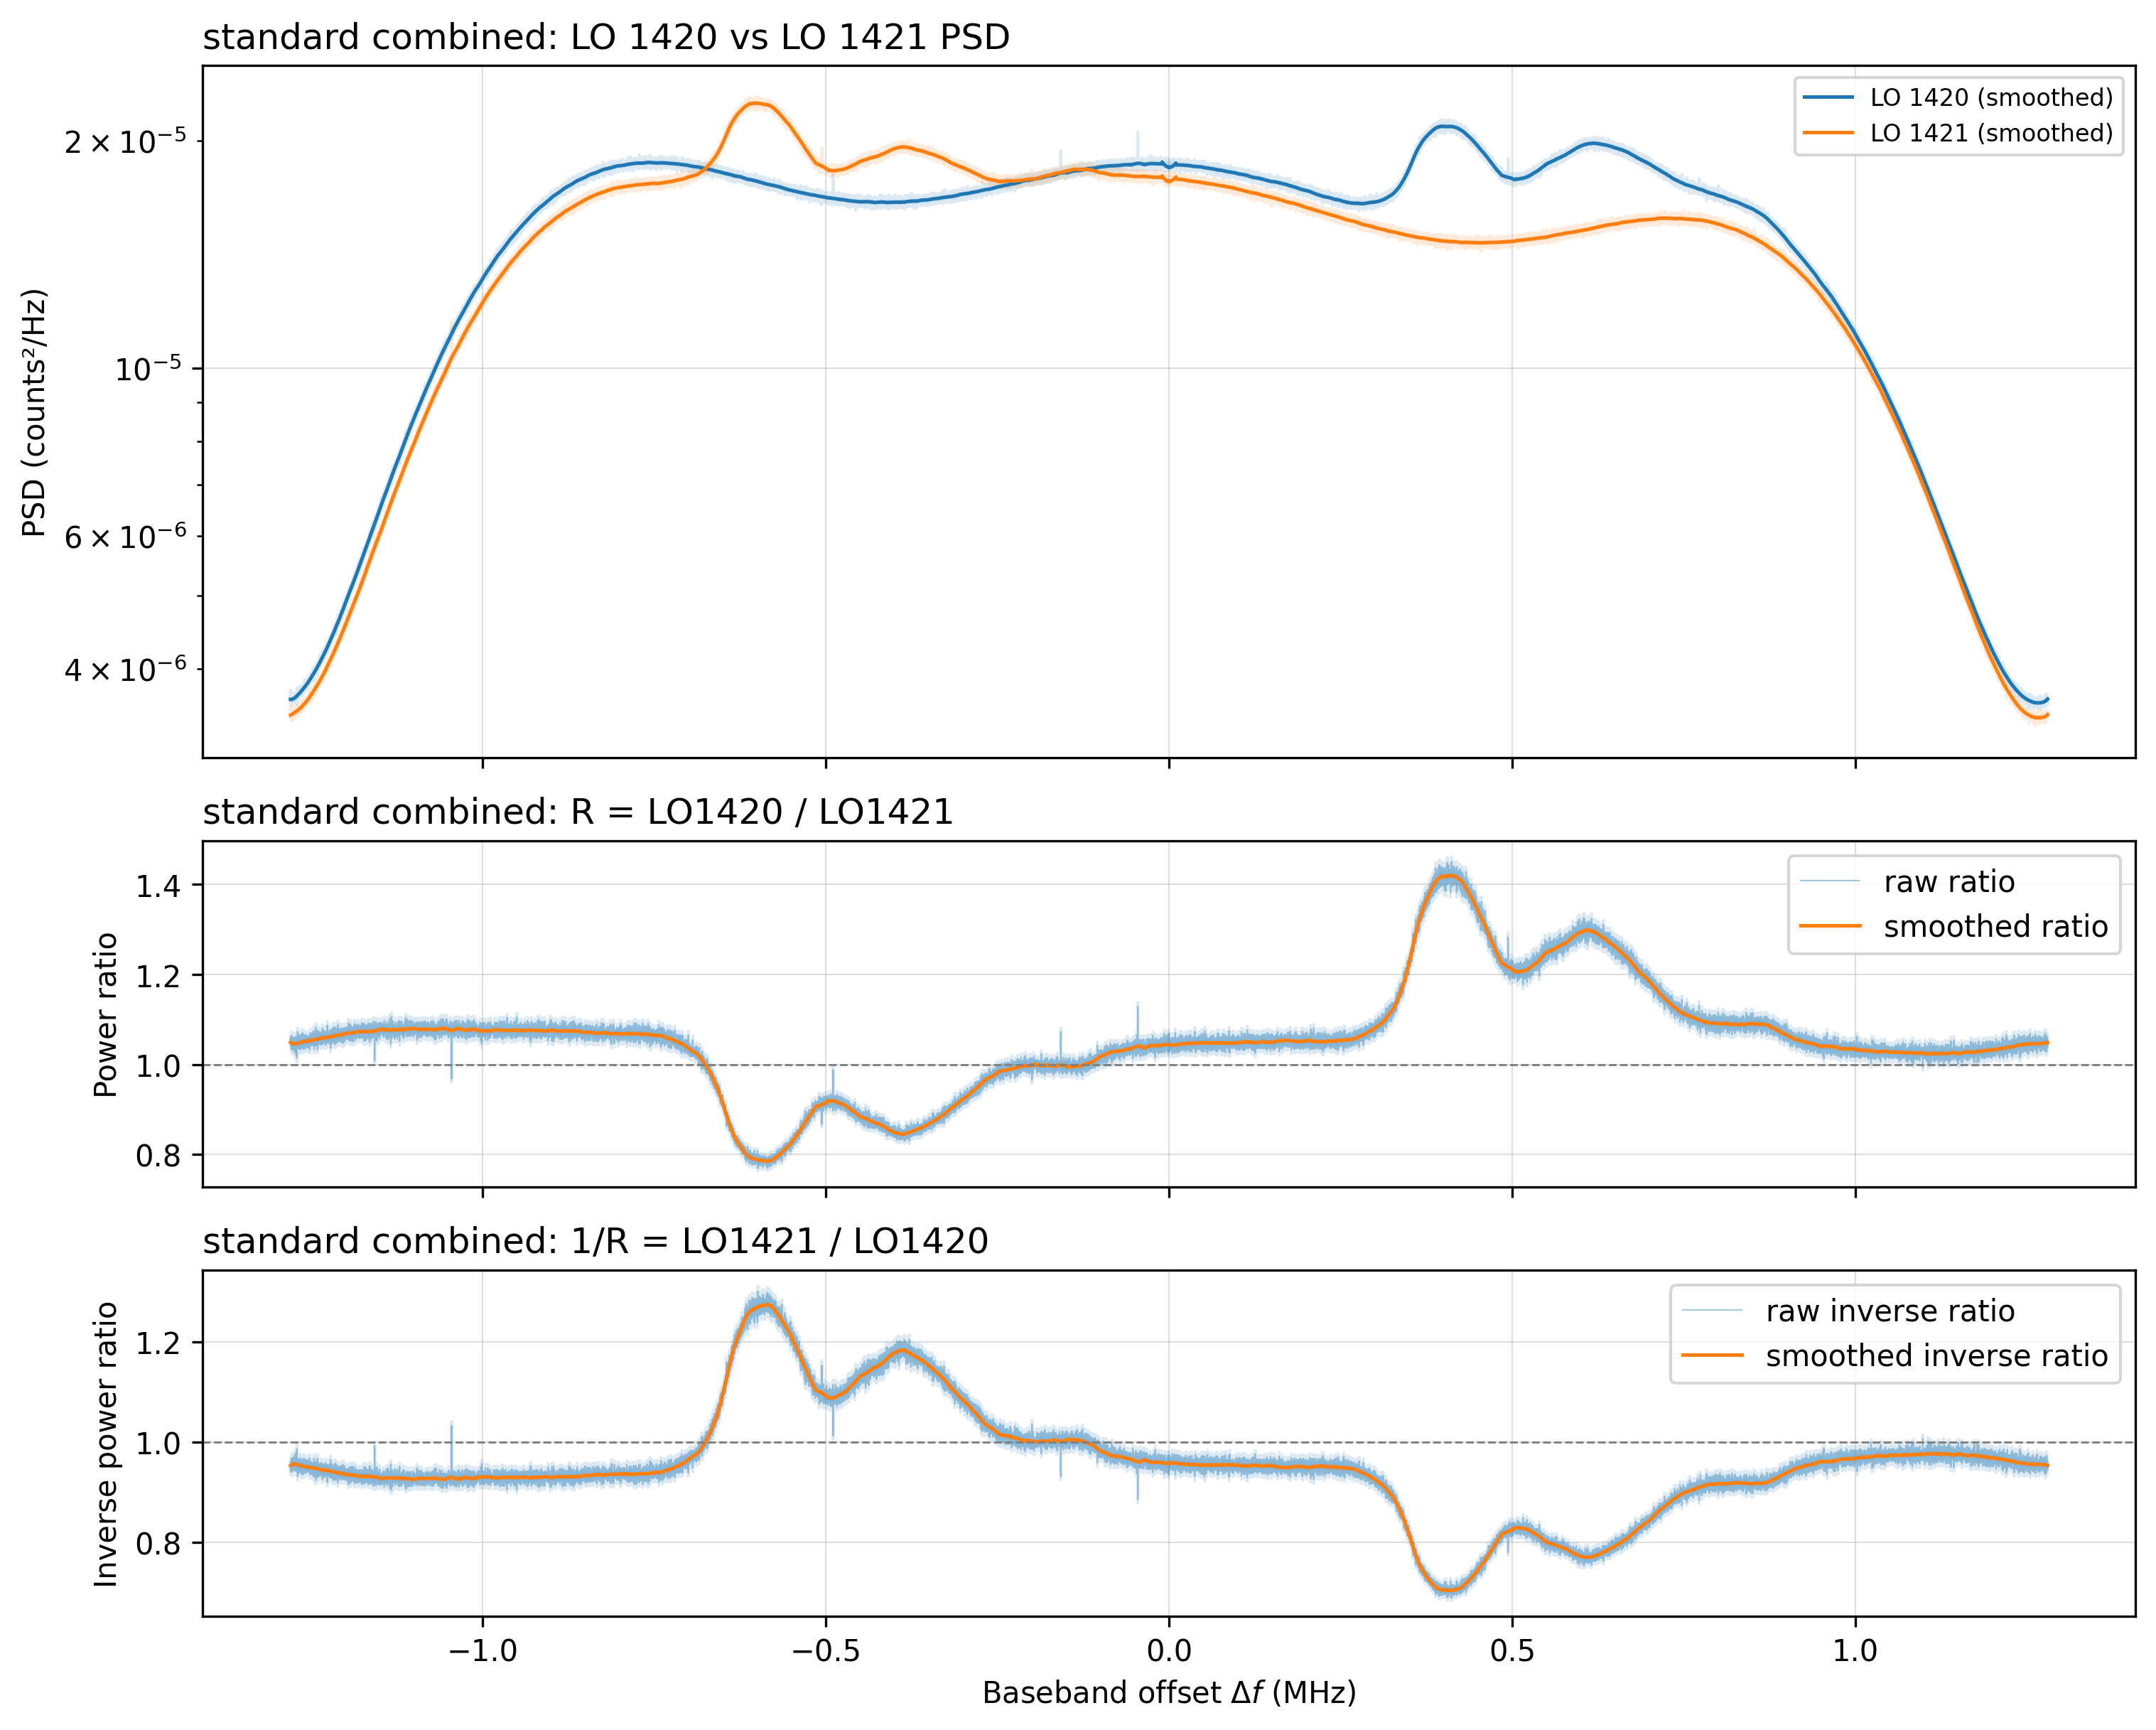


[cygnus-x]
R / 1/R summary (cygnus-x combined)
--------------------------------------------------------------------------------
total_power_1420 = 44.3148231506
total_power_1421 = 43.7443695068
R_total         = 1.0130406187
1/R_total       = 0.9871272499


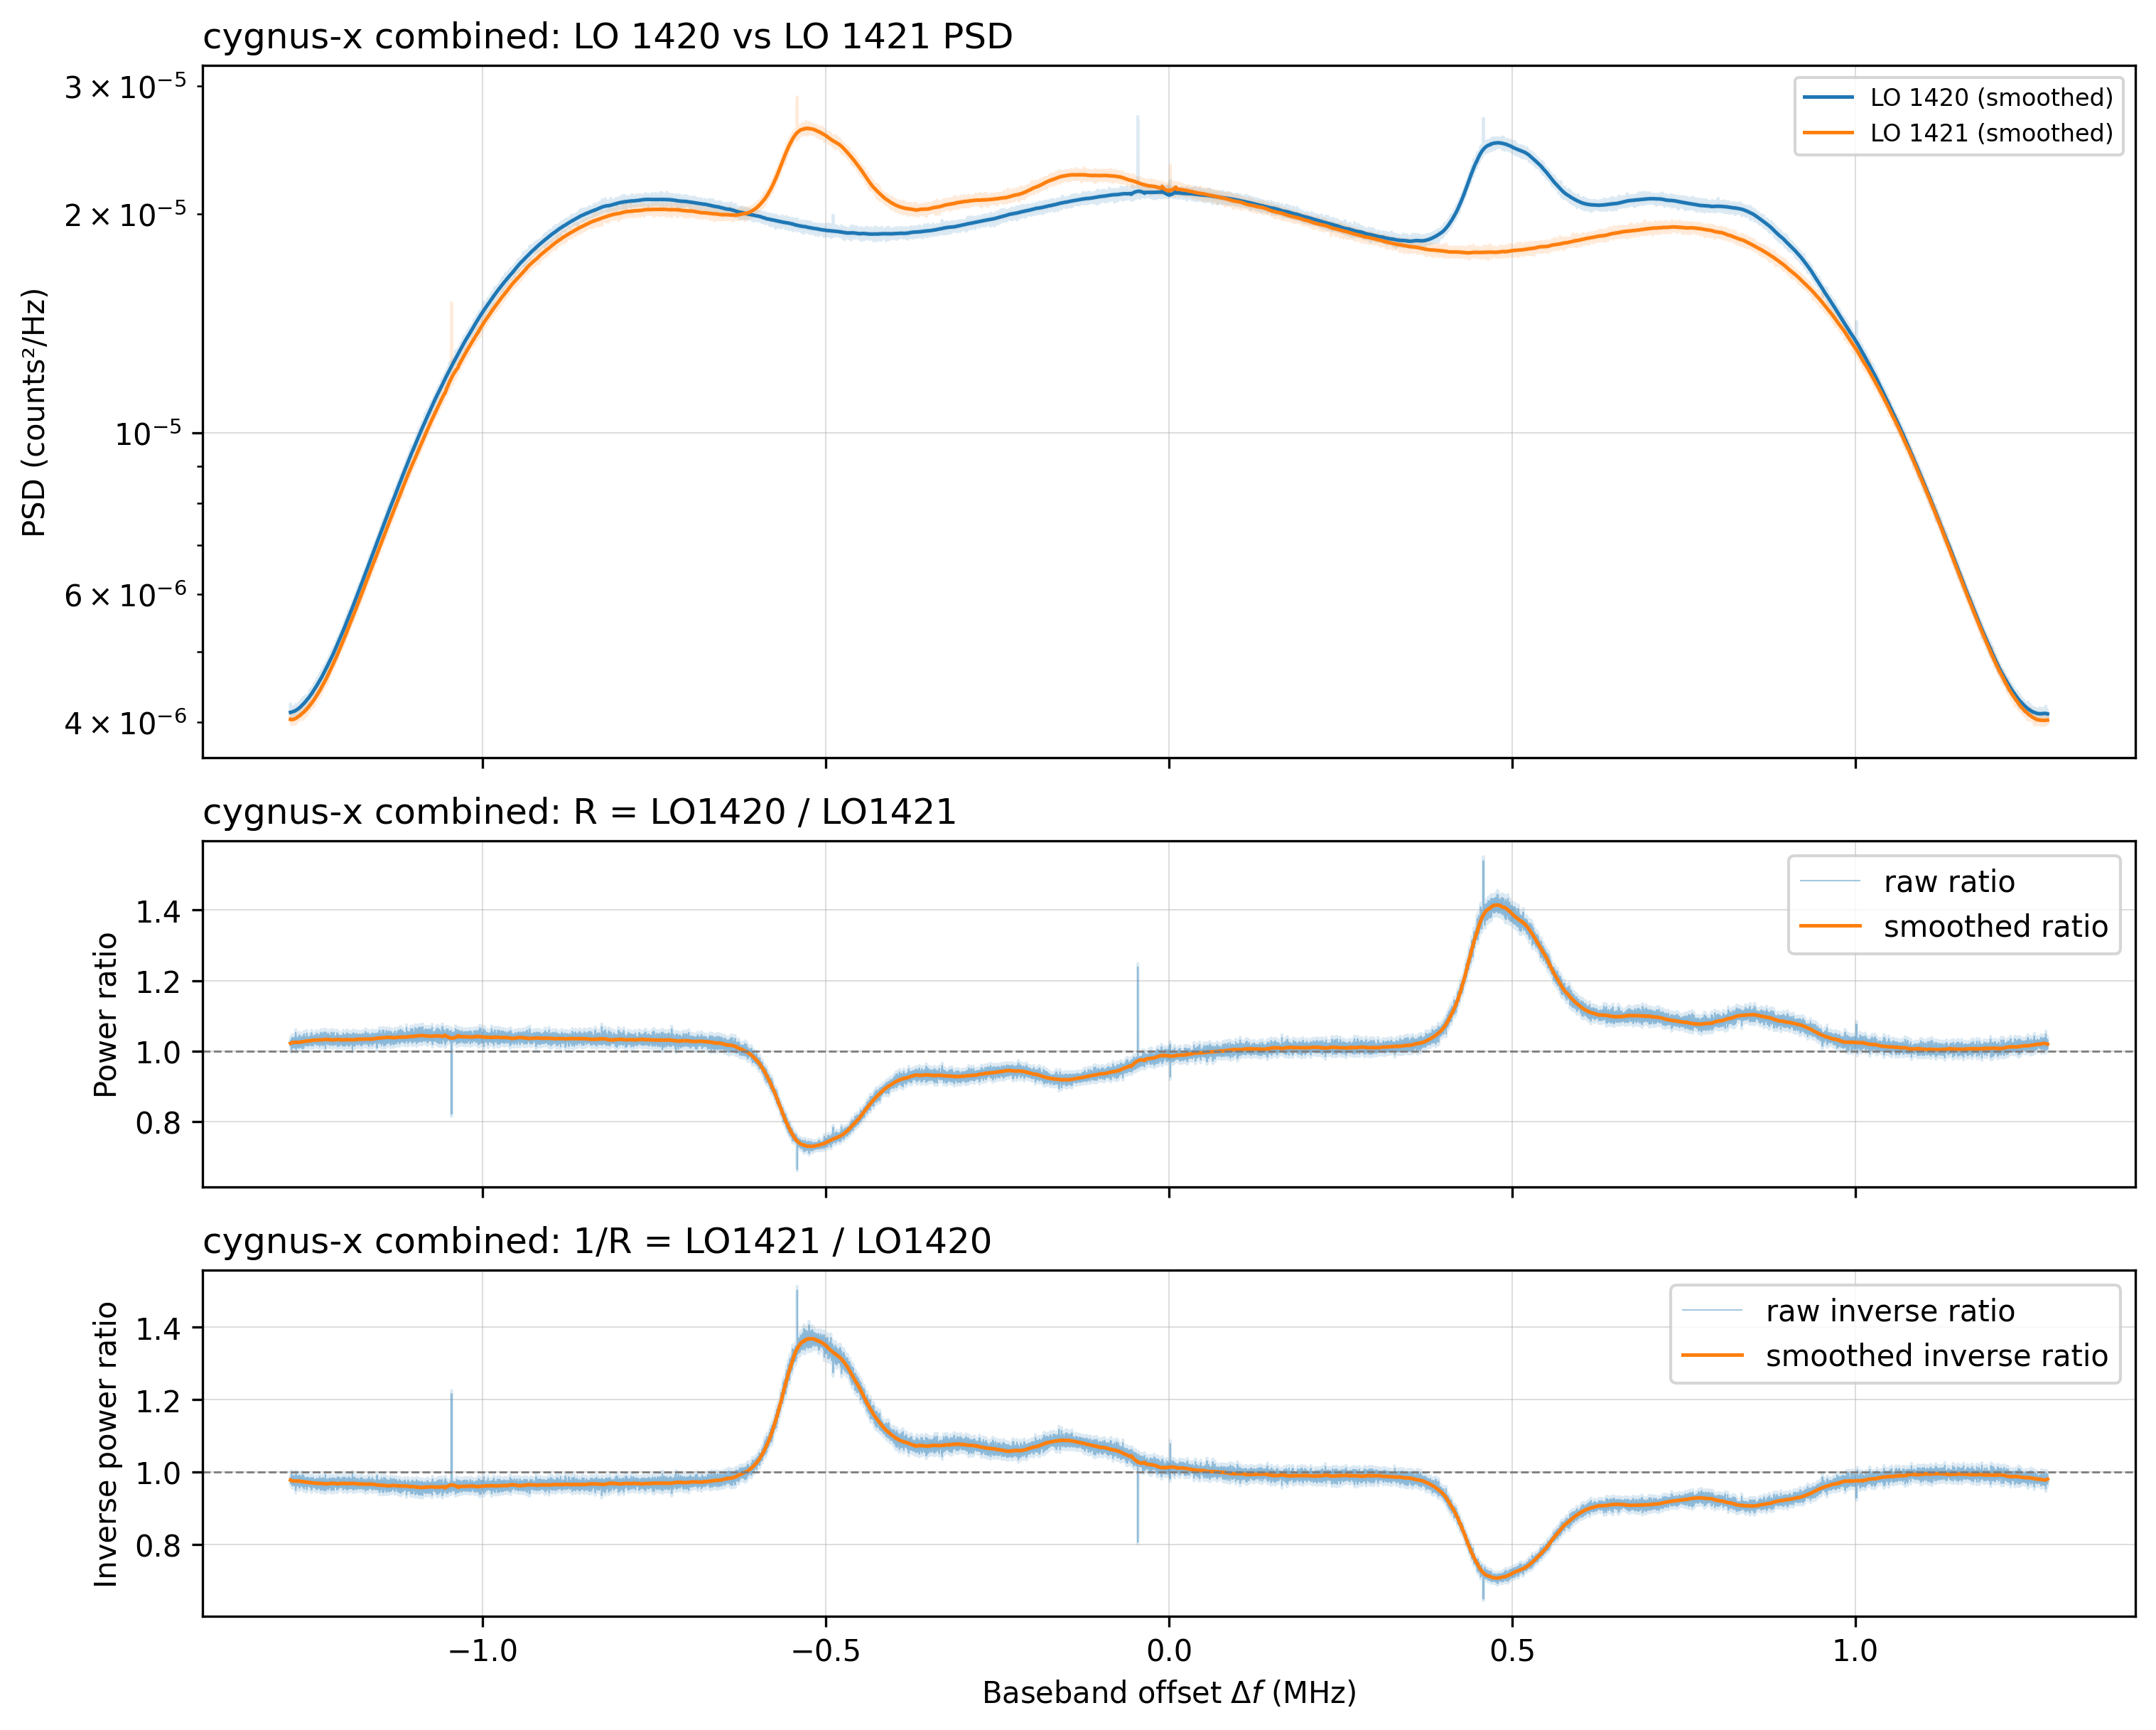


[human]
R / 1/R summary (human combined)
--------------------------------------------------------------------------------
total_power_1420 = 110.4311981201
total_power_1421 = 107.4255905151
R_total         = 1.0279785067
1/R_total       = 0.9727829847


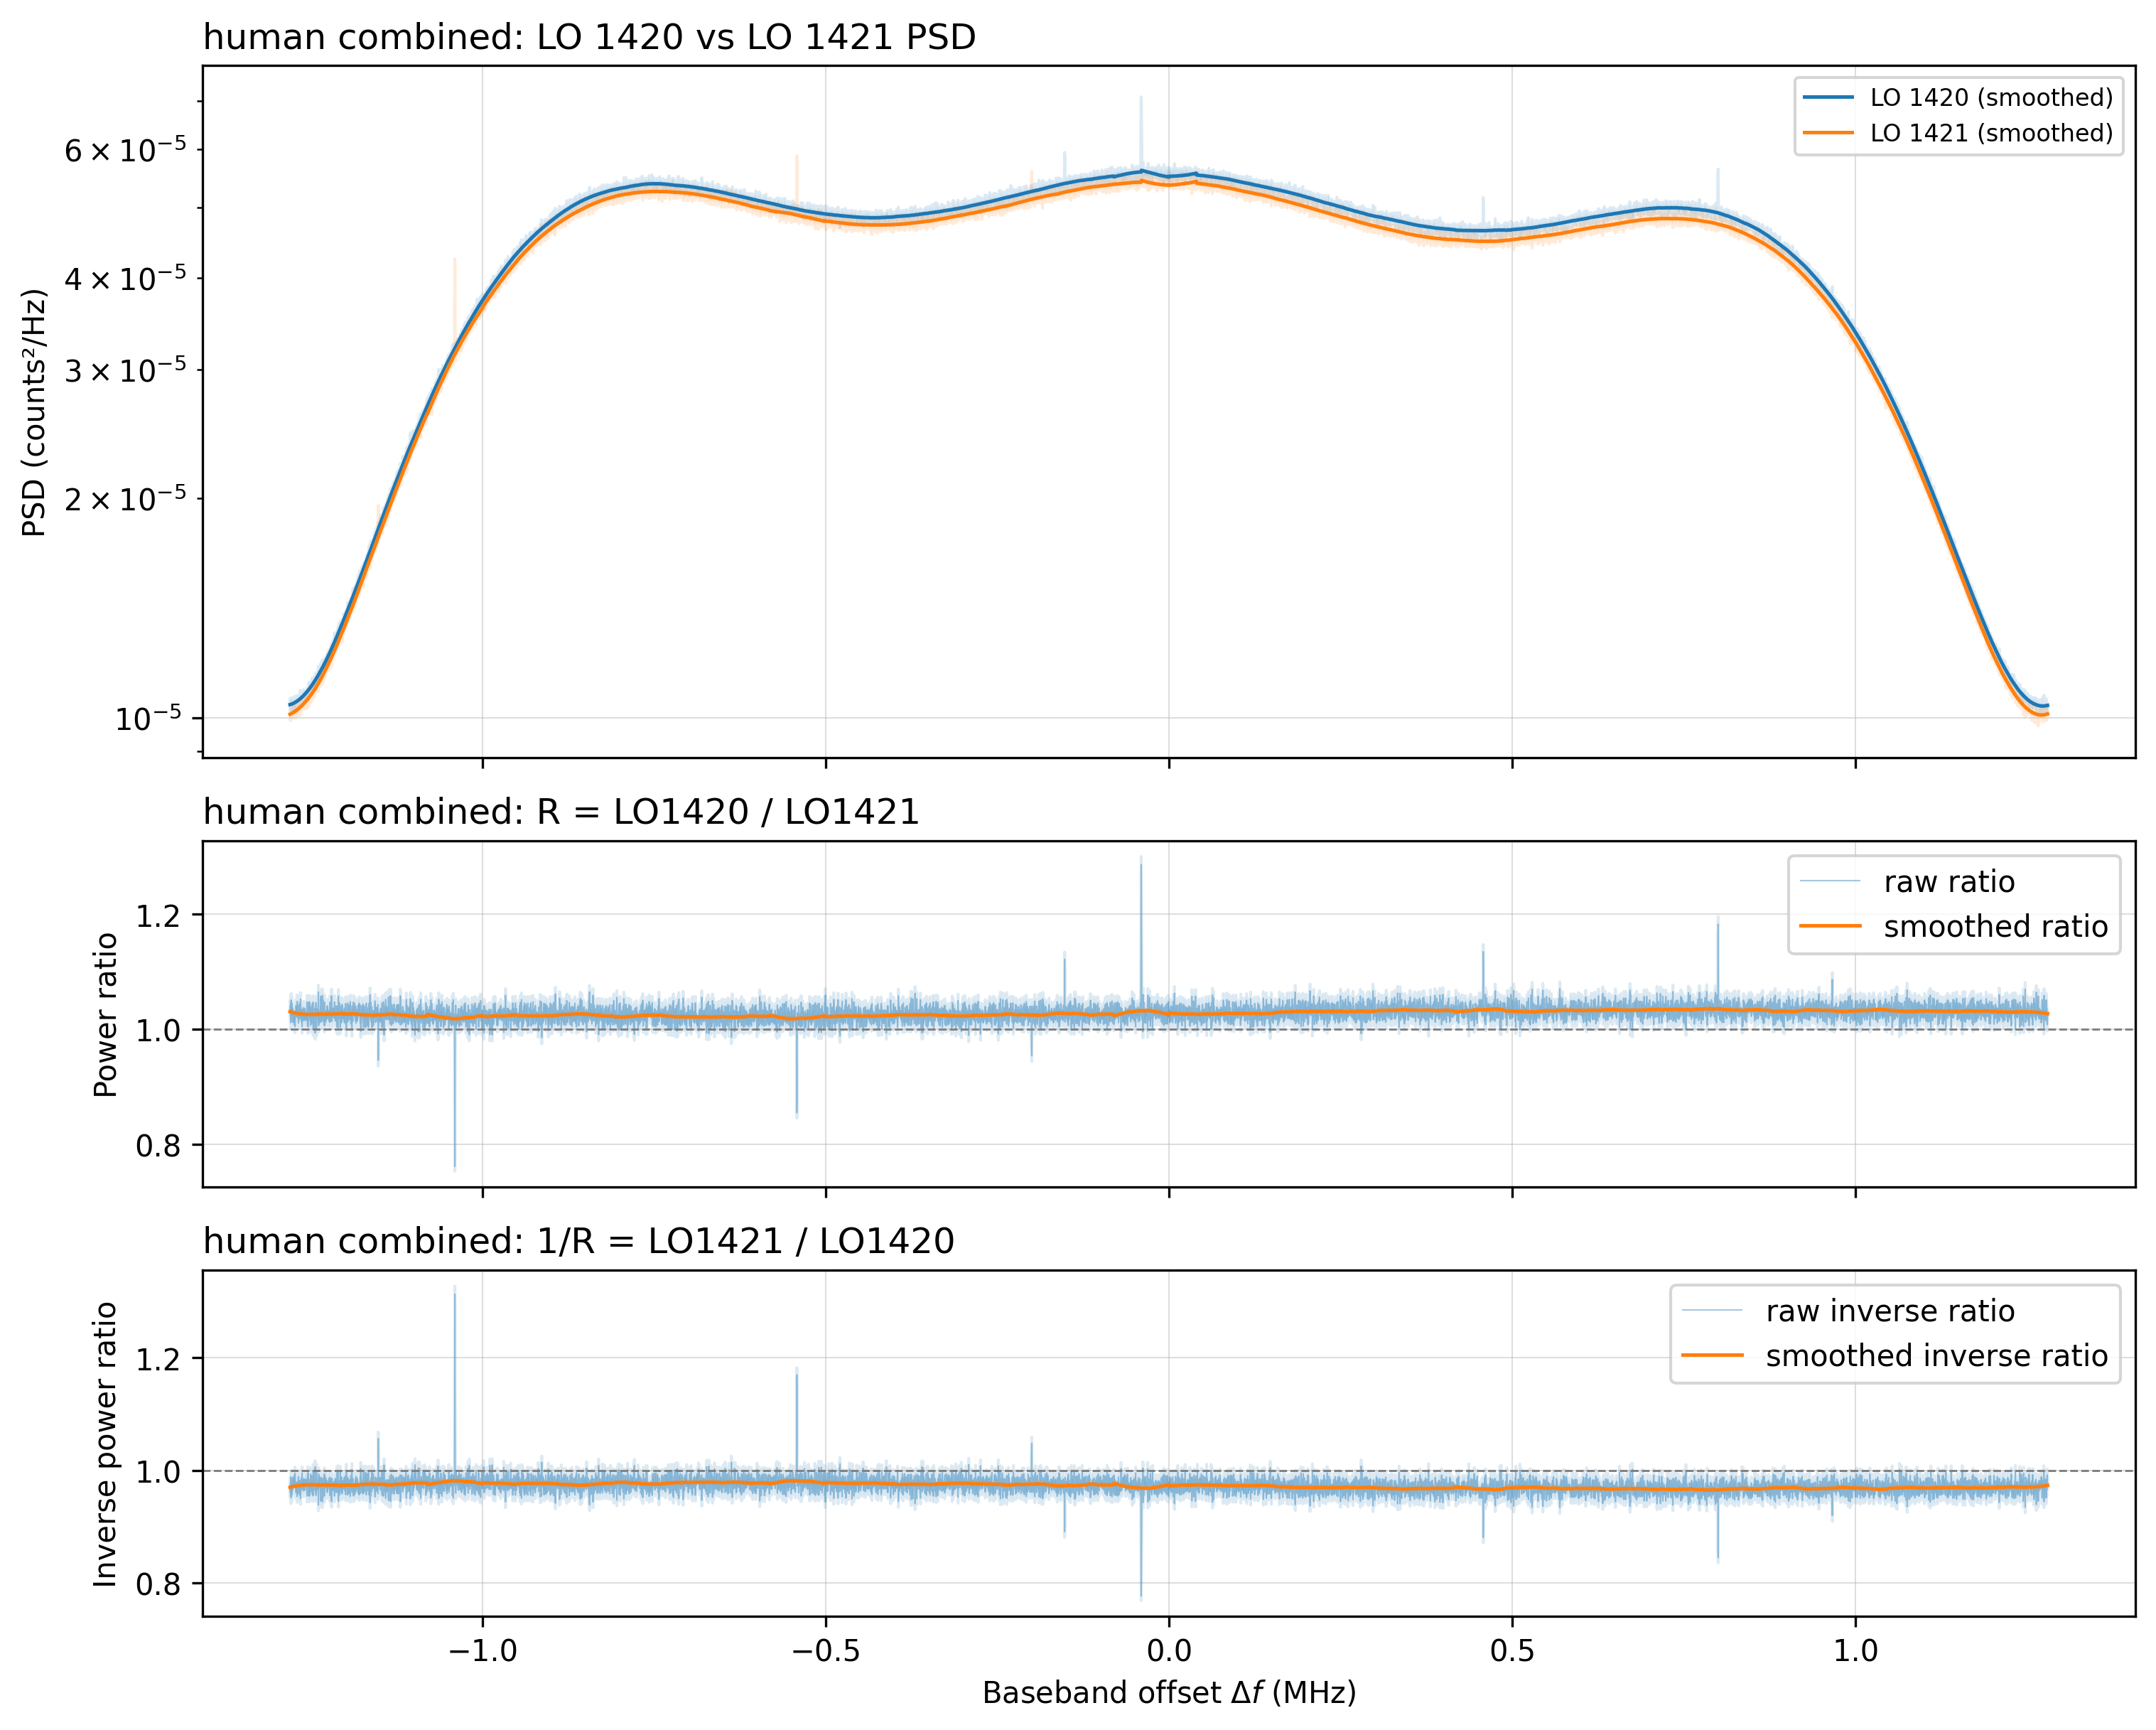


[SGP]
R / 1/R summary (SGP combined)
--------------------------------------------------------------------------------
total_power_1420 = 52.9482803345
total_power_1421 = 50.2230567932
R_total         = 1.0542623989
1/R_total       = 0.9485304617


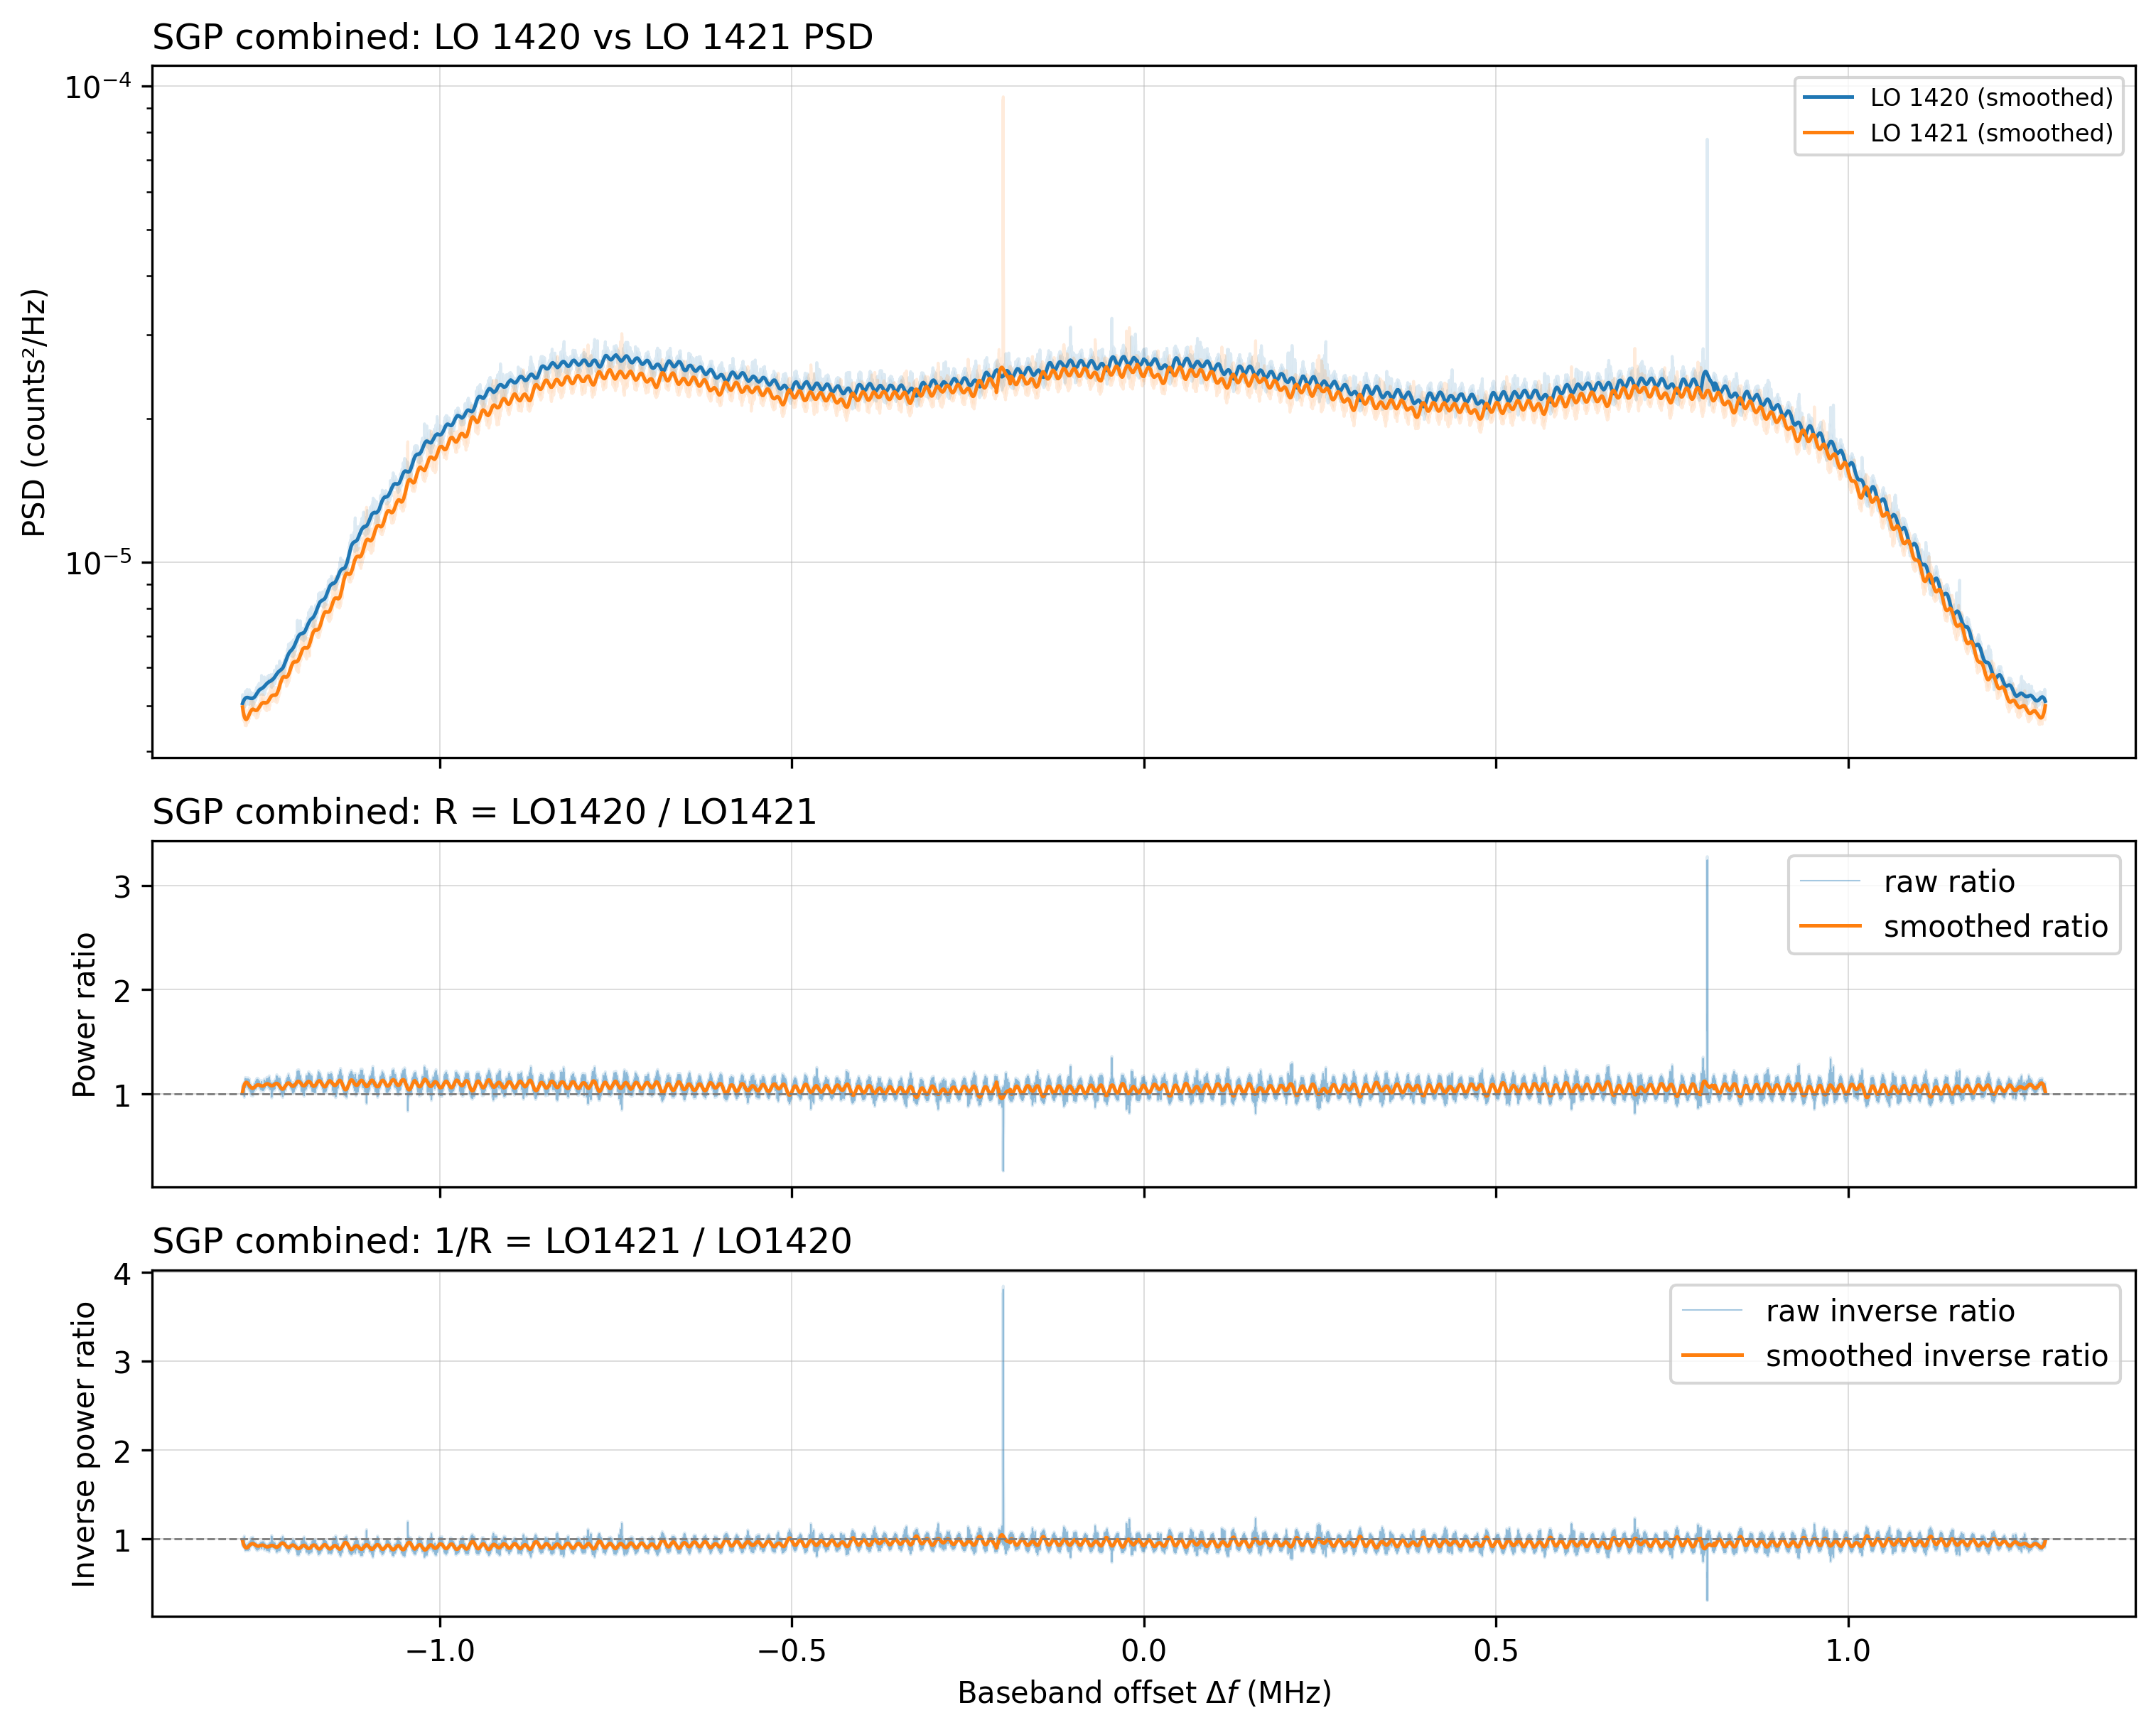


[cold_ref]
R / 1/R summary (cold_ref combined)
--------------------------------------------------------------------------------
total_power_1420 = 30.9804191589
total_power_1421 = 33.3853607178
R_total         = 0.9279641883
1/R_total       = 1.0776277928


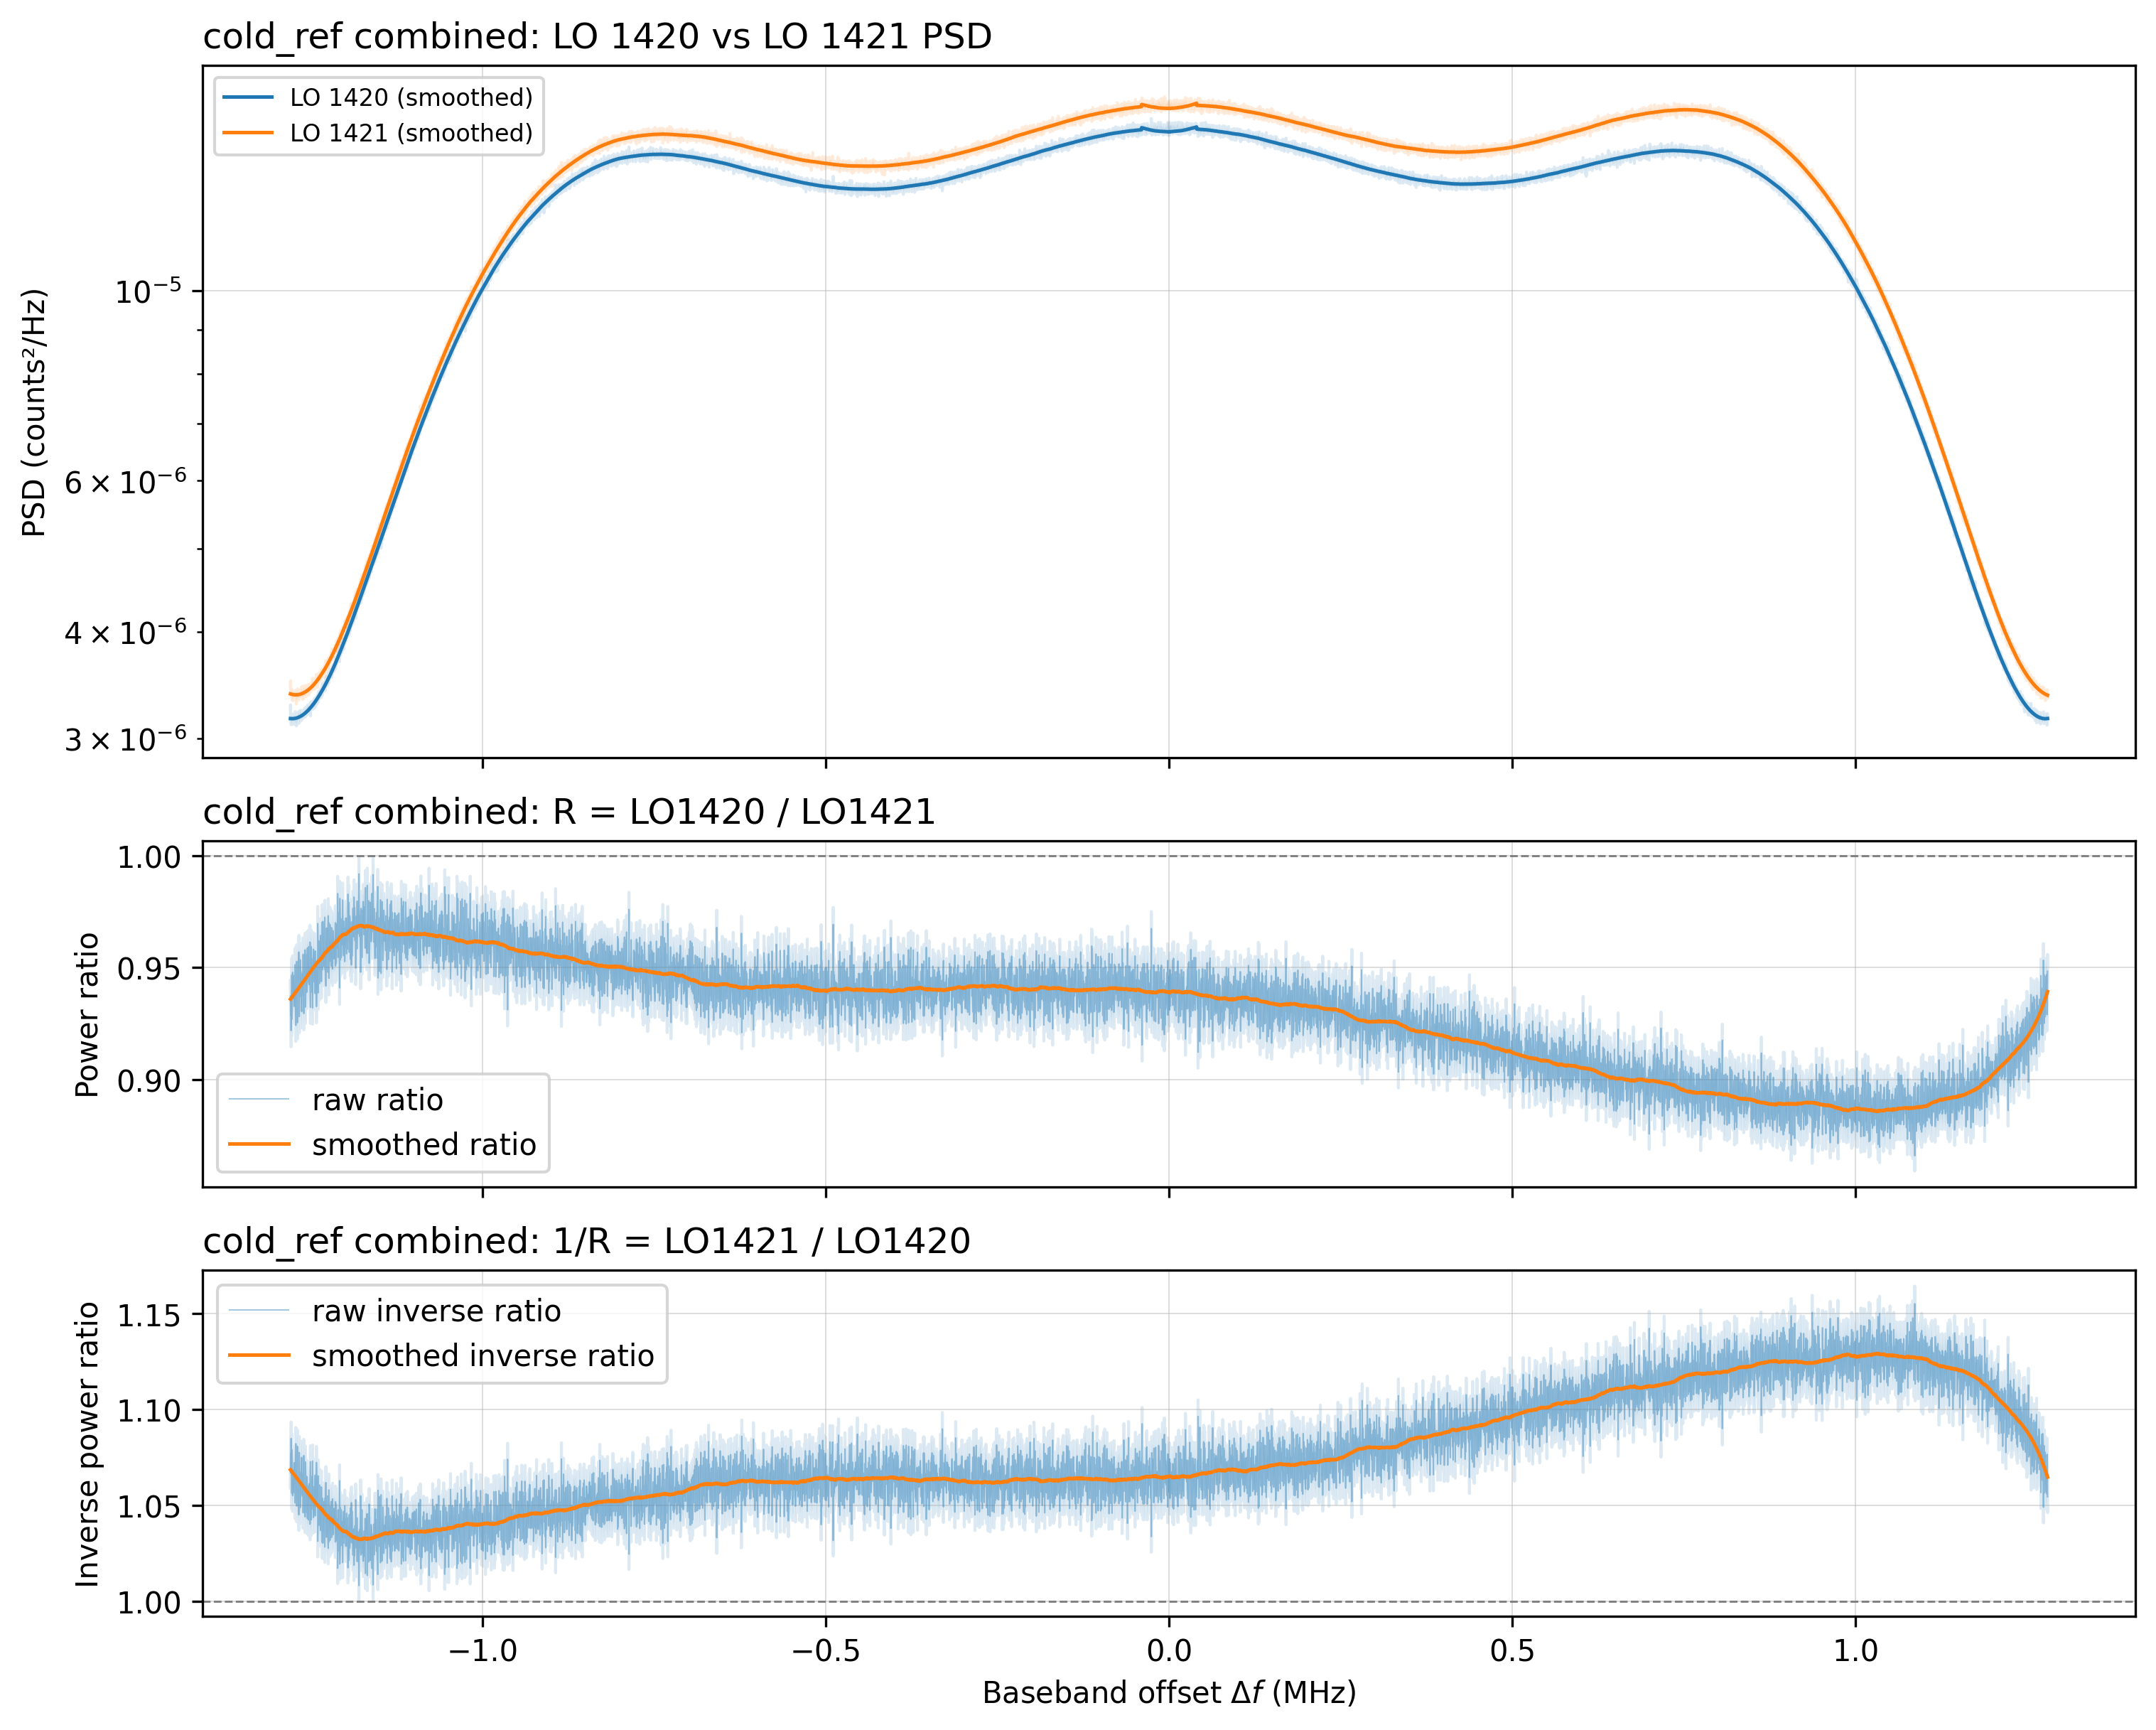

In [6]:
savgol = dict(method='savgol', window_length=257, polyorder=3)

for dataset in DATASETS:
    label = dataset['label']
    print()
    print('=' * 80)
    print(f'[{label}]')

    spec_1420 = pairs_by_dataset[label][1420]
    spec_1421 = pairs_by_dataset[label][1421]
    plot_dataset_pair(label, "combined", spec_1420, spec_1421, savgol)
